# Extract 2D HEALPix Data for ETC Storm

This notebook extracts 2D variables from HEALPix data for all timesteps of an ETC storm.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import sys
from datetime import datetime
import argparse
import intake
from easygems import healpix as egh
import healpy as hp
import matplotlib.pyplot as plt

In [2]:
def convert_time(time_array):
    """Convert cftime to standard datetime64"""
    if hasattr(time_array[0], 'year'):
        return np.array([np.datetime64(datetime(t.year, t.month, t.day, t.hour)) 
                         for t in time_array])
    return time_array

In [3]:
def extract_healpix_variable_to_latlon(
    hp_data,
    storm_lon,
    storm_lat,
    storm_time,
    hp_grid,
    nside,
    radius=10.0,
    lon_res=0.25,
    lat_res=0.25,
    x_dimname="lon",
    y_dimname="lat",
    x_coordname="lon",
    y_coordname="lat",
    pad_invalid_latitudes=True
):
    """
    Extract HEALPix variable and remap to regular lat-lon grid centered at storm location.
    Pads output with NaN for grids with invalid latitudes beyond poles.
    
    Parameters
    ----------
    hp_data : xarray.DataArray
        HEALPix variable data with 'cell' and 'time' dimensions
    storm_lon : float
        Storm center longitude
    storm_lat : float
        Storm center latitude
    storm_time : np.datetime64
        Storm time
    hp_grid : xarray.Dataset
        HEALPix grid with 'lat' and 'lon' coordinates
    nside : int
        HEALPix nside parameter
    radius : float, optional
        Radius around storm center in degrees (default: 10.0)
    lon_res : float, optional
        Longitude resolution in degrees (default: 0.25)
    lat_res : float, optional
        Latitude resolution in degrees (default: 0.25)
    x_dimname : str, optional
        Name for longitude dimension (default: "lon")
    y_dimname : str, optional
        Name for latitude dimension (default: "lat")
    x_coordname : str, optional
        Name for longitude coordinate (default: "lon")
    y_coordname : str, optional
        Name for latitude coordinate (default: "lat")
    pad_invalid_latitudes : bool, optional
        If True, pad with NaN for invalid latitudes beyond ±90° (default: True)
    
    Returns
    -------
    xarray.DataArray
        Variable remapped to regular lat-lon grid, padded with NaN if needed
    """
    # Select data at storm time
    data_at_time = hp_data.sel(time=storm_time, method="nearest").compute()
    
    # Find the closest grid points to the storm center
    lon_center = round(storm_lon / lon_res) * lon_res
    lat_center = round(storm_lat / lat_res) * lat_res
    
    # Create the FULL lat-lon grid (including invalid latitudes)
    lon_grid_full = np.arange(lon_center - radius, lon_center + radius + lon_res, lon_res)
    lat_grid_full = np.arange(lat_center - radius, lat_center + radius + lat_res, lat_res)
    
    if pad_invalid_latitudes:
        # Identify valid latitude indices (within [-90, 90])
        valid_lat_mask = (lat_grid_full >= -90.0) & (lat_grid_full <= 90.0)
        
        # If all latitudes are valid, proceed normally
        if np.all(valid_lat_mask):
            lon_grid = lon_grid_full
            lat_grid = lat_grid_full
            
            # Get HEALPix pixel indices for the grid points
            pix = xr.DataArray(
                hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid), nest=True, lonlat=True),
                coords=((y_dimname, lat_grid), (x_dimname, lon_grid)),
            )
            
            # Drop lat/lon coordinates from input data to avoid conflicts during isel
            data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
            
            # Remap variable to lat/lon grid
            data_gridded = data_dropped.isel(cell=pix)
            
        else:
            # Some latitudes are invalid - need to pad with NaN
            # Extract only valid latitudes
            lat_grid_valid = lat_grid_full[valid_lat_mask]
            lon_grid = lon_grid_full
            
            # Get HEALPix pixel indices for VALID grid points only
            pix_valid = xr.DataArray(
                hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid_valid), nest=True, lonlat=True),
                coords=((y_dimname, lat_grid_valid), (x_dimname, lon_grid)),
            )
            
            # Drop lat/lon coordinates from input data to avoid conflicts during isel
            data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
            
            # Remap variable to lat/lon grid for valid points
            data_valid = data_dropped.isel(cell=pix_valid)
            
            # Create full output array with NaN padding
            ny_full = len(lat_grid_full)
            nx_full = len(lon_grid)
            
            # Initialize full array with NaN
            full_shape = (ny_full, nx_full)
            data_full = np.full(full_shape, np.nan, dtype=data_valid.dtype)
            
            # Find indices where to place valid data
            valid_lat_indices = np.where(valid_lat_mask)[0]
            
            # Fill in the valid data
            for i, lat_idx in enumerate(valid_lat_indices):
                data_full[lat_idx, :] = data_valid.values[i, :]
            
            # Create output DataArray with full grid
            data_gridded = xr.DataArray(
                data_full,
                coords={
                    y_dimname: lat_grid_full,
                    x_dimname: lon_grid
                },
                dims=[y_dimname, x_dimname],
                attrs=data_valid.attrs
            )
    else:
        # No padding - clip to valid latitudes only
        lat_min = max(lat_center - radius, -90.0)
        lat_max = min(lat_center + radius, 90.0)
        
        lon_grid = lon_grid_full
        lat_grid = np.arange(lat_min, lat_max + lat_res, lat_res)
        
        # Get HEALPix pixel indices for the grid points
        pix = xr.DataArray(
            hp.ang2pix(nside, *np.meshgrid(lon_grid, lat_grid), nest=True, lonlat=True),
            coords=((y_dimname, lat_grid), (x_dimname, lon_grid)),
        )
        
        # Drop lat/lon coordinates from input data to avoid conflicts during isel
        data_dropped = data_at_time.drop_vars([y_coordname, x_coordname], errors='ignore')
        
        # Remap variable to lat/lon grid
        data_gridded = data_dropped.isel(cell=pix)
    
    return data_gridded

## Load HEALPix Data

In [4]:
catalog_file = "https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml"
current_location = "NERSC"

source = "scream_ne120_inst"
catalog_params = {
    "zoom": 8
}

# Read catalog
cat = intake.open_catalog(catalog_file)
if current_location:
    cat = cat[current_location]

print(f"Loading catalog {source}...")
# Load HEALPix dataset
ds = cat[source](**catalog_params).to_dask().pipe(
    egh.attach_coords, signed_lon=True
)
# Convert time coordinates to datetime64 and assign back to dataset
ds = ds.assign_coords(time=convert_time(ds.time.values))

# Get HEALPix grid
print("Computing HEALPix grid...")
hp_grid = ds[['lat', 'lon']].compute()
nside = egh.get_nside(hp_grid)
print(f"Grid: nside={nside}")

Loading catalog scream_ne120_inst...
Computing HEALPix grid...
Grid: nside=256
Computing HEALPix grid...
Grid: nside=256


/global/common/software/m1867/python/hackathon/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [19]:
# Select variable to extract
rh850 = ds["rh850"] * 100. # convert unit to %
rh850

<xarray.DataArray 'rh850' (time: 3169, cell: 786432)> Size: 10GB
dask.array<mul, shape=(3169, 786432), dtype=float32, chunksize=(24, 4096), chunktype=numpy.ndarray>
Coordinates:
    lat      (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.2984 -0.1492
    lon      (cell) float64 6MB 45.0 45.18 44.82 45.0 ... -44.82 -45.18 -45.0
    crs      int64 8B 0
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
  * time     (time) datetime64[us] 25kB 2019-08-01 ... 2020-09-01

## Load ETC Track Data

In [20]:
root_dir = "/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/"
in_file = f"{root_dir}screamv2_ne120_tracking/screamv2_ne120_hp8.etc_stitched_nodes.txt"
in_file

'/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/screamv2_ne120_tracking/screamv2_ne120_hp8.etc_stitched_nodes.txt'

In [21]:
# Parse the storm data text file
def parse_storm_file(file_path, unstructured_mesh=True):
    storm_data = []
    with open(file_path, 'r') as f:
        storm_id = 0
        for line in f:
            line = line.strip()
            if line.startswith("start"):
                # New storm
                storm_id += 1
                num_timesteps, year, month, day, hour = map(int, line.split()[1:])
            else:
                # Storm details
                cols = line.split()
                if unstructured_mesh:
                    storm_data.append({
                        "storm_id": storm_id,
                        "grid_id": int(cols[0]),
                        "lon": float(cols[1]),
                        "lat": float(cols[2]),
                        "year": int(cols[-4]),
                        "month": int(cols[-3]),
                        "day": int(cols[-2]),
                        "hour": int(cols[-1]),
                        "base_time": np.datetime64(f"{int(cols[-4]):04d}-{int(cols[-3]):02d}-{int(cols[-2]):02d}T{int(cols[-1]):02d}:00")
                    })
                else:
                    storm_data.append({
                        "storm_id": storm_id,
                        "lon_id": int(cols[0]),
                        "lat_id": int(cols[1]),
                        "lon": float(cols[2]),
                        "lat": float(cols[3]),
                        "year": int(cols[-4]),
                        "month": int(cols[-3]),
                        "day": int(cols[-2]),
                        "hour": int(cols[-1]),
                        "base_time": np.datetime64(f"{int(cols[-4]):04d}-{int(cols[-3]):02d}-{int(cols[-2]):02d}T{int(cols[-1]):02d}:00")
                    })
    return pd.DataFrame(storm_data)

In [22]:
unstructured_mesh = True
storm_df = parse_storm_file(in_file, unstructured_mesh=unstructured_mesh)
print(f"Total storm points: {len(storm_df)}")
print(f"Total unique storms: {storm_df['storm_id'].nunique()}")
storm_df.head()

Total storm points: 18704
Total unique storms: 1329


,storm_id,grid_id,lon,lat,year,month,day,hour,base_time
0,1,225172,328.349301,51.062119,2019,8,1,0,2019-08-01 00:00:00
1,1,225144,330.365876,51.836503,2019,8,1,6,2019-08-01 06:00:00
2,1,227884,332.185954,52.994706,2019,8,1,12,2019-08-01 12:00:00
3,1,227986,332.396932,53.956885,2019,8,1,18,2019-08-01 18:00:00
4,1,249882,330.896761,55.873462,2019,8,2,0,2019-08-02 00:00:00


## Extract ETC Storm 1014

In [23]:
# ETC 1014: north Pacific, 2020-05-18 18Z - 2020-05-24 18Z
# 3-way overlap period: 2020-05-15 18Z - 2020-05-22 12Z

# Extract storm 1014 data
storm_1014 = storm_df.loc[storm_df['storm_id'] == 1014].copy()
print(f"Storm 1014 has {len(storm_1014)} timesteps")
print(f"Time range: {storm_1014['base_time'].min()} to {storm_1014['base_time'].max()}")
print(f"Lat range: {storm_1014['lat'].min():.2f} to {storm_1014['lat'].max():.2f}")
print(f"Lon range: {storm_1014['lon'].min():.2f} to {storm_1014['lon'].max():.2f}")
storm_1014.head()

Storm 1014 has 17 timesteps
Time range: 2020-05-20 18:00:00 to 2020-05-24 18:00:00
Lat range: 40.42 to 57.40
Lon range: 202.15 to 212.21


,storm_id,grid_id,lon,lat,year,month,day,hour,base_time
14270,1014,167911,202.148438,40.424109,2020,5,20,18,2020-05-20 18:00:00
14271,1014,170650,204.061587,41.810446,2020,5,21,0,2020-05-21 00:00:00
14272,1014,170706,205.379970,43.008680,2020,5,21,6,2020-05-21 06:00:00
14273,1014,170812,207.222196,44.399883,2020,5,21,12,2020-05-21 12:00:00
14274,1014,171619,209.799978,47.945558,2020,5,21,18,2020-05-21 18:00:00


## Extract 2D Variable for All Timesteps

In [24]:
# Set extraction parameters
radius = 10.0  # degrees
lon_res = 0.25
lat_res = 0.25

# Calculate expected grid dimensions
ny = int(2 * radius / lat_res + 1)
nx = int(2 * radius / lon_res + 1)
print(f"Expected output grid dimensions: ({ny}, {nx})")

Expected output grid dimensions: (81, 81)


In [25]:
# Initialize output array [time, lat, lon]
ntimes = len(storm_1014)
output_array = np.full((ntimes, ny, nx), np.nan, dtype=np.float32)

# Store coordinates
times_array = []
lat_coords = None
lon_coords = None

print(f"Extracting data for {ntimes} timesteps...")

# Loop over each timestep
for idx, (row_idx, row) in enumerate(storm_1014.iterrows()):
    storm_lon = row['lon']
    storm_lat = row['lat']
    storm_time = row['base_time']
    
    if idx % 10 == 0:
        print(f"  Processing timestep {idx+1}/{ntimes}: {storm_time}")
    
    try:
        # Extract data
        data_gridded = extract_healpix_variable_to_latlon(
            hp_data=rh850,
            storm_lon=storm_lon,
            storm_lat=storm_lat,
            storm_time=storm_time,
            hp_grid=hp_grid,
            nside=nside,
            radius=radius,
            lon_res=lon_res,
            lat_res=lat_res,
            pad_invalid_latitudes=True
        )
        
        # Store data
        output_array[idx, :, :] = data_gridded.values
        
        # Store coordinates (only need to do this once)
        if lat_coords is None:
            lat_coords = data_gridded.lat.values
            lon_coords = data_gridded.lon.values
        
        times_array.append(storm_time)
        
    except Exception as e:
        print(f"  Error at timestep {idx}: {e}")
        times_array.append(storm_time)

print("\nExtraction complete!")

Extracting data for 17 timesteps...
  Processing timestep 1/17: 2020-05-20 18:00:00
  Processing timestep 11/17: 2020-05-23 06:00:00
  Processing timestep 11/17: 2020-05-23 06:00:00

Extraction complete!

Extraction complete!


In [32]:
# Create relative x and y coordinates (indices relative to storm center)
# Center is at index 0
nx_half = nx // 2
ny_half = ny // 2
x_coords = np.arange(-nx_half, nx_half + 1)
y_coords = np.arange(-ny_half, ny_half + 1)

print(f"x coordinates: {x_coords[0]} to {x_coords[-1]} (center at 0)")
print(f"y coordinates: {y_coords[0]} to {y_coords[-1]} (center at 0)")
print(f"Grid spacing: {lon_res}° lon, {lat_res}° lat")

x coordinates: -40 to 40 (center at 0)
y coordinates: -40 to 40 (center at 0)
Grid spacing: 0.25° lon, 0.25° lat


In [33]:
# Extract storm information as 1D arrays
storm_ids = storm_1014['storm_id'].values
grid_ids = storm_1014['grid_id'].values
storm_lats = storm_1014['lat'].values
storm_lons = storm_1014['lon'].values

print(f"Storm info arrays length: {len(storm_ids)}")

Storm info arrays length: 17


In [34]:
# Create xarray Dataset with the extracted data
ds_extracted = xr.Dataset(
    {
        'rh850': (['time', 'y', 'x'], output_array, {
            'long_name': 'Relative Humidity at 850 hPa',
            'units': '%',
            'description': 'Extracted around ETC storm center'
        }),
        'storm_id': (['time'], storm_ids, {
            'long_name': 'Storm ID',
            'description': 'ETC storm identifier'
        }),
        'grid_id': (['time'], grid_ids, {
            'long_name': 'HEALPix Grid ID',
            'description': 'HEALPix cell index at storm center'
        }),
        'storm_lat': (['time'], storm_lats, {
            'long_name': 'Storm Center Latitude',
            'units': 'degrees_north'
        }),
        'storm_lon': (['time'], storm_lons, {
            'long_name': 'Storm Center Longitude',
            'units': 'degrees_east'
        })
    },
    coords={
        'time': times_array,
        'y': (['y'], y_coords, {
            'long_name': 'y index relative to storm center',
            'units': 'grid points',
            'description': f'Latitude index relative to storm center, spacing={lat_res}°'
        }),
        'x': (['x'], x_coords, {
            'long_name': 'x index relative to storm center',
            'units': 'grid points',
            'description': f'Longitude index relative to storm center, spacing={lon_res}°'
        })
    },
    attrs={
        'storm_id': 1014,
        'radius': radius,
        'lon_res': lon_res,
        'lat_res': lat_res,
        'grid_center_x': 0,
        'grid_center_y': 0,
        'description': 'ETC storm 1014 extracted 2D data with relative coordinates'
    }
)

ds_extracted

<xarray.Dataset> Size: 448kB
Dimensions:    (time: 17, y: 81, x: 81)
Coordinates:
  * time       (time) datetime64[ns] 136B 2020-05-20T18:00:00 ... 2020-05-24T...
  * y          (y) int64 648B -40 -39 -38 -37 -36 -35 -34 ... 35 36 37 38 39 40
  * x          (x) int64 648B -40 -39 -38 -37 -36 -35 -34 ... 35 36 37 38 39 40
Data variables:
    rh850      (time, y, x) float32 446kB 40.7 67.17 67.17 ... 57.23 57.23 54.73
    storm_id   (time) int64 136B 1014 1014 1014 1014 ... 1014 1014 1014 1014
    grid_id    (time) int64 136B 167911 170650 170706 ... 188512 188482 183020
    storm_lat  (time) float64 136B 40.42 41.81 43.01 44.4 ... 56.83 56.26 56.06
    storm_lon  (time) float64 136B 202.1 204.1 205.4 207.2 ... 209.9 210.9 212.2
Attributes:
    storm_id:       1014
    radius:         10.0
    lon_res:        0.25
    lat_res:        0.25
    grid_center_x:  0
    grid_center_y:  0
    description:    ETC storm 1014 extracted 2D data with relative coordinates

In [35]:
# Check data statistics
print("Data array shape:", output_array.shape)
print(f"Total values: {output_array.size}")
print(f"NaN values: {np.isnan(output_array).sum()} ({100*np.isnan(output_array).sum()/output_array.size:.2f}%)")
print(f"Valid values: {np.sum(~np.isnan(output_array))}")
print(f"\nData range: {np.nanmin(output_array):.2f} to {np.nanmax(output_array):.2f}")

Data array shape: (17, 81, 81)
Total values: 111537
NaN values: 0 (0.00%)
Valid values: 111537

Data range: 0.00 to 102.40


In [36]:
output_array.max()

np.float32(102.39668)

## Visualize Sample Timesteps

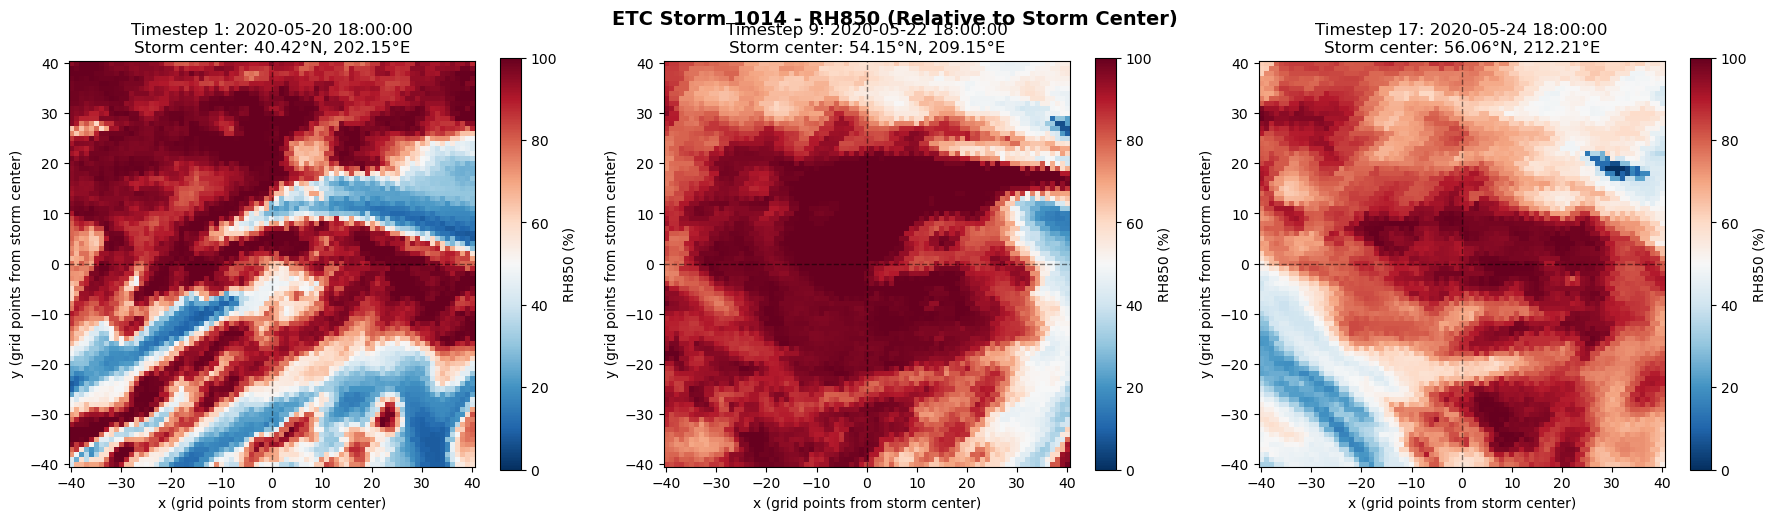

In [41]:
# Plot first, middle, and last timesteps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

timesteps_to_plot = [0, ntimes//2, ntimes-1]

for i, t_idx in enumerate(timesteps_to_plot):
    ax = axes[i]
    im = ax.pcolormesh(x_coords, y_coords, output_array[t_idx, :, :], 
                       cmap='RdBu_r', vmin=0, vmax=100)
    ax.set_xlabel('x (grid points from storm center)')
    ax.set_ylabel('y (grid points from storm center)')
    ax.set_title(f"Timestep {t_idx+1}: {times_array[t_idx]}\n" + 
                 f"Storm center: {storm_lats[t_idx]:.2f}°N, {storm_lons[t_idx]:.2f}°E")
    ax.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, label='RH850 (%)')

plt.suptitle('ETC Storm 1014 - RH850 (Relative to Storm Center)', fontsize=14, fontweight='bold')
plt.tight_layout()

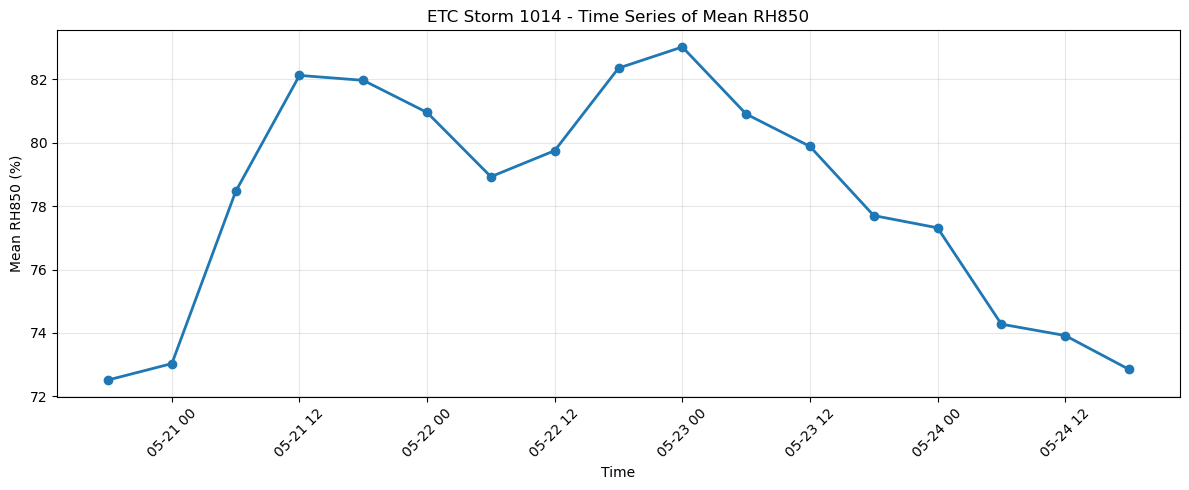

In [38]:
# Plot time series of mean RH850 around storm center
mean_rh850 = np.nanmean(output_array, axis=(1, 2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(times_array, mean_rh850, marker='o', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Mean RH850 (%)')
ax.set_title('ETC Storm 1014 - Time Series of Mean RH850')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

## Save Extracted Data

In [39]:
# Optional: Save to netCDF file
output_dir = f"/pscratch/sd/w/wcmca1/hackathon/etc_data/tests/{source}/"
os.makedirs(output_dir, exist_ok=True)

output_file = f"{output_dir}etc_storm_1014_rh850_extracted.nc"

# Set encoding for compression
encoding = {
    'rh850': {'zlib': True, 'complevel': 4, 'dtype': 'float32'}
}

ds_extracted.to_netcdf(output_file, encoding=encoding)
print(f"Saved extracted data to: {output_file}")

Saved extracted data to: /pscratch/sd/w/wcmca1/hackathon/etc_data/tests/scream_ne120_inst/etc_storm_1014_rh850_extracted.nc
